In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [71]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\mywork\Ipl_Analysis\/data/ipl_cleaned.csv", low_memory=False)

In [72]:
df.shape

(278205, 58)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 58 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           278205 non-null  int64  
 1   date               278205 non-null  object 
 2   innings            278205 non-null  int64  
 3   batting_team       278205 non-null  object 
 4   bowling_team       278205 non-null  object 
 5   over               278205 non-null  int64  
 6   ball               278205 non-null  int64  
 7   batter             278205 non-null  object 
 8   bat_pos            278205 non-null  int64  
 9   runs_batter        278205 non-null  int64  
 10  balls_faced        278205 non-null  int64  
 11  bowler             278205 non-null  object 
 12  valid_ball         278205 non-null  int64  
 13  runs_extras        278205 non-null  int64  
 14  runs_total         278205 non-null  int64  
 15  runs_bowler        278205 non-null  int64  
 16  ru

In [74]:
df.describe()

,match_id,innings,over,ball,bat_pos,runs_batter,balls_faced,valid_ball,runs_extras,runs_total,runs_bowler,non_striker_pos,runs_target,day,month,year,balls_per_over,overs,event_match_no,team_runs,team_balls,team_wicket,batter_runs,batter_balls,bowler_wicket,ipl_season,win_margin
count,2.782050e+05,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.00000,278205.000000,278205.000000,133903.000000,278205.000000,278205.000000,278205.000000,278205.0,278205.0,261492.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,273503.000000
mean,9.422687e+05,1.482914,9.193839,3.488855,3.612555,1.277378,0.967362,0.963182,0.067971,1.34535,1.320807,3.604367,169.815912,15.875516,4.787933,2016.710178,6.0,20.0,31.541703,77.110498,58.614637,2.456972,18.327424,14.011211,0.045470,2016.710178,17.400785
std,3.817198e+05,0.502571,5.681511,1.708263,2.168978,1.651107,0.177687,0.188315,0.343033,1.63762,1.642110,2.179181,32.224907,8.536507,1.586724,5.248572,0.0,0.0,18.449697,49.957873,34.117619,2.100374,18.578093,11.833930,0.208333,5.248572,21.749924
min,3.359820e+05,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,43.000000,1.000000,3.000000,2008.000000,6.0,20.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,1.000000
25%,5.483530e+05,1.000000,4.000000,2.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,150.000000,9.000000,4.000000,2012.000000,6.0,20.0,16.000000,36.000000,29.000000,1.000000,4.000000,5.000000,0.000000,2012.000000,6.000000
50%,1.082601e+06,1.000000,9.000000,3.000000,3.000000,1.000000,1.000000,1.000000,0.000000,1.00000,1.000000,3.000000,169.000000,16.000000,4.000000,2017.000000,6.0,20.0,31.000000,73.000000,58.000000,2.000000,12.000000,11.000000,0.000000,2017.000000,8.000000
75%,1.304049e+06,2.000000,14.000000,5.000000,5.000000,1.000000,1.000000,1.000000,0.000000,1.00000,1.000000,5.000000,190.000000,23.000000,5.000000,2022.000000,6.0,20.0,46.000000,113.000000,88.000000,4.000000,27.000000,20.000000,0.000000,2022.000000,20.000000
max,1.485779e+06,6.000000,19.000000,7.000000,11.000000,6.000000,1.000000,1.000000,7.000000,7.00000,7.000000,11.000000,288.000000,31.000000,11.000000,2025.000000,6.0,20.0,72.000000,287.000000,121.000000,10.000000,175.000000,73.000000,1.000000,2025.000000,146.000000


In [75]:
df["match_id"].nunique()

1169

In [76]:
df["ipl_season"].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype=int64)

In [77]:
df["ipl_season"].nunique()

18

In [78]:
df["batter"].nunique()

703

In [79]:

df["bowler"].nunique()

550

In [80]:
match_df = df.groupby("match_id").agg({
    "ipl_season": "first",
    "date": "first",
    "venue": "first",
    "city": "first",
    "match_won_by": "first",
    "win_margin": "first",
    "win_type": "first",
    "result_type": "first",
    "toss_winner": "first",
    "toss_decision": "first"
}).reset_index()

match_df.head()

,match_id,ipl_season,date,venue,city,match_won_by,win_margin,win_type,result_type,toss_winner,toss_decision
0,335982,2008,2008-04-18,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,Kolkata Knight Riders,140.0,runs,normal,Royal Challengers Bengaluru,field
1,335983,2008,2008-04-19,"Punjab Cricket Association IS Bindra Stadium, ...",Mohali,Chennai Super Kings,33.0,runs,normal,Chennai Super Kings,bat
2,335984,2008,2008-04-19,"Arun Jaitley Stadium, Delhi",Delhi,Delhi Capitals,9.0,wickets,normal,Rajasthan Royals,bat
3,335985,2008,2008-04-20,"Wankhede Stadium, Mumbai",Mumbai,Royal Challengers Bengaluru,5.0,wickets,normal,Mumbai Indians,bat
4,335986,2008,2008-04-20,"Eden Gardens, Kolkata",Kolkata,Kolkata Knight Riders,5.0,wickets,normal,Deccan Chargers,bat


In [81]:
team_df = df[df["innings"] == 1].groupby("match_id").agg({
    "batting_team": "first",
    "bowling_team": "first"
}).reset_index()

team_df = team_df.rename(columns={
    "batting_team": "team1",
    "bowling_team": "team2"
})

match_info = df.groupby("match_id").agg({
    "ipl_season": "first",
    "date": "first",
    "venue": "first",
    "city": "first",
    "match_won_by": "first",
    "win_margin": "first",
    "win_type": "first",
    "result_type": "first",
    "toss_winner": "first",
    "toss_decision": "first"
}).reset_index()

match_df = match_info.merge(team_df, on="match_id", how="left")

match_df.head()

,match_id,ipl_season,date,venue,city,match_won_by,win_margin,win_type,result_type,toss_winner,toss_decision,team1,team2
0,335982,2008,2008-04-18,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,Kolkata Knight Riders,140.0,runs,normal,Royal Challengers Bengaluru,field,Kolkata Knight Riders,Royal Challengers Bengaluru
1,335983,2008,2008-04-19,"Punjab Cricket Association IS Bindra Stadium, ...",Mohali,Chennai Super Kings,33.0,runs,normal,Chennai Super Kings,bat,Chennai Super Kings,Punjab Kings
2,335984,2008,2008-04-19,"Arun Jaitley Stadium, Delhi",Delhi,Delhi Capitals,9.0,wickets,normal,Rajasthan Royals,bat,Rajasthan Royals,Delhi Capitals
3,335985,2008,2008-04-20,"Wankhede Stadium, Mumbai",Mumbai,Royal Challengers Bengaluru,5.0,wickets,normal,Mumbai Indians,bat,Mumbai Indians,Royal Challengers Bengaluru
4,335986,2008,2008-04-20,"Eden Gardens, Kolkata",Kolkata,Kolkata Knight Riders,5.0,wickets,normal,Deccan Chargers,bat,Deccan Chargers,Kolkata Knight Riders


In [82]:
match_df.shape

(1169, 13)

In [83]:
matches_per_season = match_df.groupby("ipl_season")["match_id"].count()

matches_per_season

ipl_season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
Name: match_id, dtype: int64

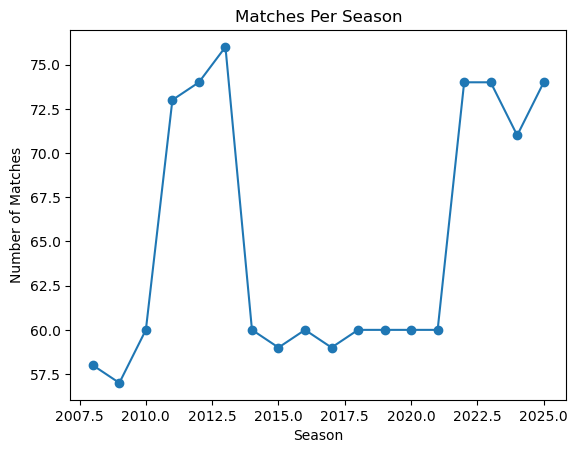

In [84]:
plt.figure()
matches_per_season.plot(kind="line", marker="o")
plt.title("Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

In [85]:
first_innings = df[
    (df["innings"] == 1) & 
    (df["is_super_over"] == False)
]

first_innings_score = first_innings.groupby(
    ["match_id", "ipl_season"]
)["team_runs"].max().reset_index()

first_innings_score.head()

,match_id,ipl_season,team_runs
0,335982,2008,222
1,335983,2008,240
2,335984,2008,129
3,335985,2008,165
4,335986,2008,110


In [86]:
avg_first_innings = first_innings_score.groupby(
    "ipl_season"
)["team_runs"].mean()

avg_first_innings

ipl_season
2008    160.965517
2009    150.263158
2010    164.783333
2011    152.369863
2012    157.540541
2013    155.894737
2014    163.066667
2015    166.254237
2016    162.600000
2017    165.779661
2018    172.466667
2019    166.733333
2020    169.500000
2021    159.316667
2022    171.121622
2023    182.729730
2024    189.591549
2025    188.837838
Name: team_runs, dtype: float64

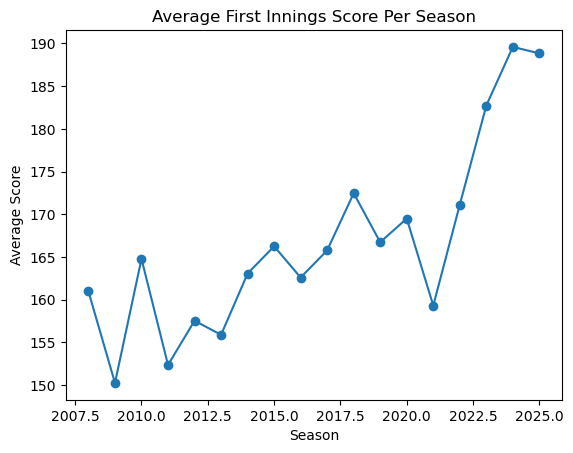

In [87]:
plt.figure()
avg_first_innings.plot(kind="line", marker="o")
plt.title("Average First Innings Score Per Season")
plt.xlabel("Season")
plt.ylabel("Average Score")
plt.show()

In [88]:
win_type_counts = match_df["win_type"].value_counts()
win_type_counts

win_type
wickets    615
runs       531
Name: count, dtype: int64

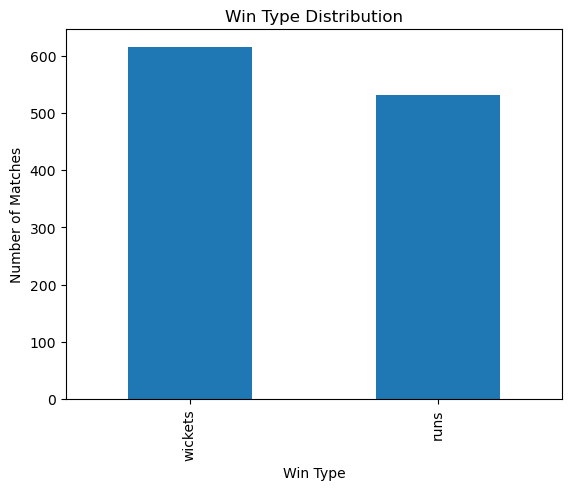

In [89]:
plt.figure()
win_type_counts.plot(kind="bar")
plt.title("Win Type Distribution")
plt.xlabel("Win Type")
plt.ylabel("Number of Matches")
plt.show()

In [90]:
match_df["toss_win_match_win"] = match_df["toss_winner"] == match_df["match_won_by"]

In [91]:
match_df["toss_win_match_win"].value_counts()

toss_win_match_win
True     591
False    578
Name: count, dtype: int64

In [92]:
(match_df["toss_win_match_win"].mean()) * 100

50.556030795551756

In [93]:
match_df["toss_decision"].value_counts()

toss_decision
field    764
bat      405
Name: count, dtype: int64

In [94]:
toss_decision_win = match_df.groupby("toss_decision")["toss_win_match_win"].mean() * 100
toss_decision_win

toss_decision
bat      45.185185
field    53.403141
Name: toss_win_match_win, dtype: float64

In [95]:
chasing_trend = match_df.groupby("ipl_season").apply(
    lambda x: (x["win_type"] == "wickets").mean() * 100
)

chasing_trend

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7896\1059627098.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chasing_trend = match_df.groupby("ipl_season").apply(


ipl_season
2008    58.620690
2009    50.877193
2010    46.666667
2011    53.424658
2012    54.054054
2013    48.684211
2014    61.666667
2015    40.677966
2016    65.000000
2017    54.237288
2018    53.333333
2019    58.333333
2020    48.333333
2021    61.666667
2022    50.000000
2023    44.594595
2024    50.704225
2025    50.000000
dtype: float64

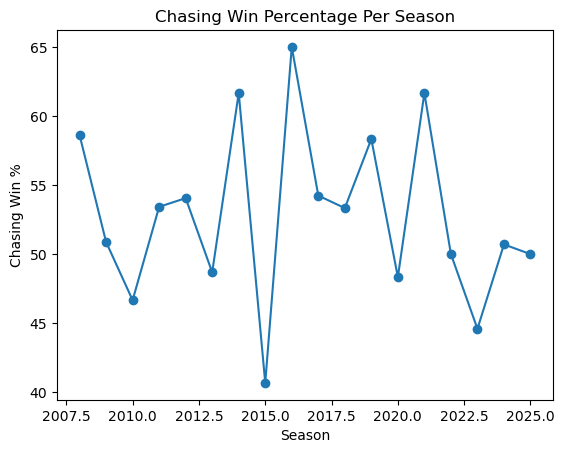

In [96]:
plt.figure()
chasing_trend.plot(kind="line", marker="o")
plt.title("Chasing Win Percentage Per Season")
plt.xlabel("Season")
plt.ylabel("Chasing Win %")
plt.show()

In [97]:
match_df = match_df.merge(
    first_innings_score[["match_id", "team_runs"]],
    on="match_id",
    how="left"
)

match_df = match_df.rename(columns={"team_runs": "first_innings_score"})

In [98]:
match_df["score_bucket"] = pd.cut(
    match_df["first_innings_score"],
    bins=[0,150,170,190,300],
    labels=["Below 150","150-170","170-190","190+"]
)

In [99]:
bucket_analysis = match_df.groupby("score_bucket")["win_type"].apply(
    lambda x: (x == "wickets").mean() * 100
)

bucket_analysis

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7896\2833199175.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_analysis = match_df.groupby("score_bucket")["win_type"].apply(


score_bucket
Below 150    75.294118
150-170      57.770270
170-190      47.426471
190+         22.605364
Name: win_type, dtype: float64

In [100]:
venue_scoring = first_innings_score.merge(
    match_df[["match_id","venue"]],
    on="match_id"
)

venue_avg = venue_scoring.groupby("venue")["team_runs"].mean().sort_values(ascending=False)

venue_avg.head(10)

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam       208.750000
Sawai Mansingh Stadium, Jaipur                                           187.235294
Narendra Modi Stadium, Ahmedabad                                         186.636364
Himachal Pradesh Cricket Association Stadium, Dharamsala                 183.133333
Brabourne Stadium                                                        180.400000
Brabourne Stadium, Mumbai                                                177.411765
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow    175.363636
Barsapara Cricket Stadium, Guwahati                                      174.600000
M Chinnaswamy Stadium, Bengaluru                                         172.979798
Arun Jaitley Stadium, Delhi                                              171.773196
Name: team_runs, dtype: float64

In [101]:
venue_count = venue_scoring.groupby("venue")["match_id"].count()

venue_analysis = pd.concat([venue_avg, venue_count], axis=1)
venue_analysis.columns = ["avg_score", "match_count"]

venue_analysis.sort_values("avg_score", ascending=False).head(10)

,avg_score,match_count
venue,,
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",208.750000,4
"Sawai Mansingh Stadium, Jaipur",187.235294,17
"Narendra Modi Stadium, Ahmedabad",186.636364,33
"Himachal Pradesh Cricket Association Stadium, Dharamsala",183.133333,15
Brabourne Stadium,180.400000,10
"Brabourne Stadium, Mumbai",177.411765,17
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",175.363636,22
"Barsapara Cricket Stadium, Guwahati",174.600000,5
"M Chinnaswamy Stadium, Bengaluru",172.979798,99


In [102]:
df[df["venue"].str.contains("Chandigarh", case=False, na=False)]["venue"].value_counts()

venue
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           14476
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh     2561
Name: count, dtype: int64

In [103]:
match_df[match_df["ipl_season"] == 2025]["venue"].value_counts()

venue
Narendra Modi Stadium, Ahmedabad                                           9
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow      8
Eden Gardens, Kolkata                                                      7
Wankhede Stadium, Mumbai                                                   7
Sawai Mansingh Stadium, Jaipur                                             7
Arun Jaitley Stadium, Delhi                                                7
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       6
MA Chidambaram Stadium, Chepauk, Chennai                                   6
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    6
M Chinnaswamy Stadium, Bengaluru                                           5
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         2
Barsapara Cricket Stadium, Guwahati                                        2
Himachal Pradesh Cricket Association Stadium, Dharamsala              

In [141]:
team_scoring = first_innings.groupby(
    ["match_id", "batting_team"]
)["team_runs"].max().reset_index()

team_avg_score = team_scoring.groupby("batting_team")["team_runs"].mean().sort_values(ascending=False)

team_avg_score

batting_team
Lucknow Super Giants           185.090909
Gujarat Titans                 184.407407
Sunrisers Hyderabad            170.245098
Chennai Super Kings            170.088235
Royal Challengers Bengaluru    169.478261
Mumbai Indians                 168.405594
Punjab Kings                   165.604317
Kolkata Knight Riders          165.015873
Rajasthan Royals               164.214953
Delhi Capitals                 162.781513
Gujarat Lions                  161.928571
Rising Pune Supergiants        161.800000
Deccan Chargers                157.325581
Pune Warriors                  148.650000
Kochi Tuskers Kerala           144.142857
Name: team_runs, dtype: float64

In [147]:
team_match_count = team_scoring.groupby("batting_team")["match_id"].count()

team_analysis = pd.concat([team_avg_score, team_match_count], axis=1)
team_analysis.columns = ["avg_score", "match_count"]

team_analysis.sort_values("avg_score", ascending=False)

,avg_score,match_count
batting_team,,
Lucknow Super Giants,185.090909,33
Gujarat Titans,184.407407,27
Sunrisers Hyderabad,170.245098,102
Chennai Super Kings,170.088235,136
Royal Challengers Bengaluru,169.478261,138
Mumbai Indians,168.405594,143
Punjab Kings,165.604317,139
Kolkata Knight Riders,165.015873,126
Rajasthan Royals,164.214953,107


In [149]:
filtered_team_analysis = team_analysis[team_analysis["match_count"] >= 100]

filtered_team_analysis.sort_values("avg_score", ascending=False)

,avg_score,match_count
batting_team,,
Sunrisers Hyderabad,170.245098,102
Chennai Super Kings,170.088235,136
Royal Challengers Bengaluru,169.478261,138
Mumbai Indians,168.405594,143
Punjab Kings,165.604317,139
Kolkata Knight Riders,165.015873,126
Rajasthan Royals,164.214953,107
Delhi Capitals,162.781513,119


In [151]:
team1_matches = match_df["team1"].value_counts()
team2_matches = match_df["team2"].value_counts()

total_matches_played = team1_matches.add(team2_matches, fill_value=0)

total_wins = match_df["match_won_by"].value_counts()

win_percentage = (total_wins / total_matches_played) * 100

win_percentage.sort_values(ascending=False)

Gujarat Titans                 61.666667
Chennai Super Kings            56.349206
Mumbai Indians                 54.512635
Lucknow Super Giants           51.724138
Kolkata Knight Riders          51.136364
Rising Pune Supergiants        50.000000
Royal Challengers Bengaluru    48.888889
Rajasthan Royals               48.510638
Sunrisers Hyderabad            47.448980
Punjab Kings                   45.075758
Delhi Capitals                 44.194757
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Deccan Chargers                38.666667
Pune Warriors                  26.086957
Name: count, dtype: float64

In [153]:
chasing_matches = match_df.copy()

# Create column for chasing team
chasing_matches["chasing_team"] = chasing_matches.apply(
    lambda row: row["team1"] if row["win_type"] == "runs" else row["team2"],
    axis=1
)

In [155]:
chasing_wins = match_df[match_df["win_type"] == "wickets"]["match_won_by"].value_counts()

In [157]:
total_chasing = chasing_matches["chasing_team"].value_counts()

In [159]:
chasing_win_pct = (chasing_wins / total_chasing) * 100

chasing_win_pct.sort_values(ascending=False)

Gujarat Lions                  92.307692
Kochi Tuskers Kerala           66.666667
Rising Pune Supergiants        61.538462
Gujarat Titans                 59.459459
Rajasthan Royals               58.974359
Delhi Capitals                 58.196721
Kolkata Knight Riders          56.934307
Royal Challengers Bengaluru    52.238806
Punjab Kings                   51.639344
Mumbai Indians                 49.019608
Chennai Super Kings            48.611111
Sunrisers Hyderabad            46.464646
Pune Warriors                  46.153846
Deccan Chargers                37.931034
Lucknow Super Giants           33.333333
Name: count, dtype: float64

In [161]:
defending_wins = match_df[match_df["win_type"] == "runs"]["match_won_by"].value_counts()

In [163]:
defending_matches = chasing_matches.copy()

defending_matches["defending_team"] = defending_matches.apply(
    lambda row: row["team1"],
    axis=1
)

total_defending = defending_matches["defending_team"].value_counts()

In [165]:
defending_win_pct = (defending_wins / total_defending) * 100

defending_win_pct.sort_values(ascending=False)

Lucknow Super Giants           60.606061
Gujarat Titans                 55.555556
Mumbai Indians                 53.146853
Chennai Super Kings            52.941176
Rising Pune Supergiants        46.666667
Sunrisers Hyderabad            46.078431
Kolkata Knight Riders          45.238095
Royal Challengers Bengaluru    44.927536
Rajasthan Royals               42.056075
Deccan Chargers                41.860465
Punjab Kings                   40.287770
Delhi Capitals                 39.495798
Pune Warriors                  30.000000
Kochi Tuskers Kerala           28.571429
Gujarat Lions                   7.142857
Name: count, dtype: float64

In [167]:
match_df = match_df.merge(
    df.groupby("match_id")["city"].first(),
    on="match_id",
    how="left"
)

In [191]:
home_city_map = {
    "Chennai Super Kings": ["Chennai"],
    "Mumbai Indians": ["Mumbai"],
    "Royal Challengers Bengaluru": ["Bengaluru"],
    "Kolkata Knight Riders": ["Kolkata"],
    "Rajasthan Royals": ["Jaipur"],
    "Delhi Capitals": ["Delhi"],
    "Sunrisers Hyderabad": ["Hyderabad"],
    "Punjab Kings": ["Mohali", "New Chandigarh"],
    "Gujarat Titans": ["Ahmedabad"],
    "Lucknow Super Giants": ["Lucknow"]
}

In [189]:
def determine_home(row):
    for team, cities in home_city_map.items():
        if row["venue"] in cities:
            if row["team1"] == team:
                return team
            elif row["team2"] == team:
                return team
    return None

match_df["home_team"] = match_df.apply(determine_home, axis=1)

In [187]:
home_matches = match_df[match_df["home_team"].notna()]

home_win_pct = (
    home_matches[home_matches["home_team"] == home_matches["match_won_by"]]
    ["home_team"].value_counts()
    /
    home_matches["home_team"].value_counts()
) * 100

home_win_pct.sort_values(ascending=False)

Series([], Name: count, dtype: float64)

In [199]:
primary_home.head(130)

,ipl_season,batting_team,venue,match_id
0,2008,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk, Chennai",4
1,2008,Deccan Chargers,"Rajiv Gandhi International Stadium, Uppal, Hyd...",5
2,2008,Delhi Capitals,"Arun Jaitley Stadium, Delhi",4
3,2008,Kolkata Knight Riders,"Eden Gardens, Kolkata",5
4,2008,Mumbai Indians,"Dr DY Patil Sports Academy, Mumbai",2
...,...,...,...,...
125,2022,Sunrisers Hyderabad,"Wankhede Stadium, Mumbai",3
126,2023,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk, Chennai",5
127,2023,Delhi Capitals,"Arun Jaitley Stadium, Delhi",2
128,2023,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",7


In [201]:
match_df.iloc[0]

match_id                                         335982
ipl_season                                         2008
date                                         2008-04-18
venue                  M Chinnaswamy Stadium, Bengaluru
city_x                                        Bengaluru
match_won_by                      Kolkata Knight Riders
win_margin                                        140.0
win_type                                           runs
result_type                                      normal
toss_winner                 Royal Challengers Bengaluru
toss_decision                                     field
team1                             Kolkata Knight Riders
team2                       Royal Challengers Bengaluru
toss_win_match_win                                False
first_innings_score                                 222
score_bucket                                       190+
city_y                                        Bengaluru
home_team                                       

In [203]:
def determine_home_dynamic(row):
    season = row["ipl_season"]
    venue = row["venue"]

    team1_home = primary_home[
        (primary_home["ipl_season"] == season) &
        (primary_home["batting_team"] == row["team1"])
    ]["venue"].values

    team2_home = primary_home[
        (primary_home["ipl_season"] == season) &
        (primary_home["batting_team"] == row["team2"])
    ]["venue"].values

    if len(team1_home) > 0 and venue == team1_home[0]:
        return row["team1"]
    elif len(team2_home) > 0 and venue == team2_home[0]:
        return row["team2"]
    else:
        return None

match_df["home_team"] = match_df.apply(determine_home_dynamic, axis=1)

In [205]:
match_df["home_team"].value_counts()

home_team
Kolkata Knight Riders          107
Royal Challengers Bengaluru    106
Delhi Capitals                 100
Chennai Super Kings             99
Mumbai Indians                  99
Punjab Kings                    80
Rajasthan Royals                76
Sunrisers Hyderabad             69
Gujarat Titans                  26
Lucknow Super Giants            24
Pune Warriors                   22
Deccan Chargers                 20
Rising Pune Supergiants         11
Kochi Tuskers Kerala             5
Gujarat Lions                    4
Name: count, dtype: int64

In [207]:
home_matches = match_df[match_df["home_team"].notna()]

home_wins = home_matches[
    home_matches["home_team"] == home_matches["match_won_by"]
]

home_win_pct = (
    home_wins["home_team"].value_counts() /
    home_matches["home_team"].value_counts()
) * 100

home_win_pct.sort_values(ascending=False)

home_team
Chennai Super Kings            62.626263
Mumbai Indians                 60.606061
Rajasthan Royals               55.263158
Kolkata Knight Riders          54.205607
Gujarat Titans                 53.846154
Sunrisers Hyderabad            52.173913
Royal Challengers Bengaluru    46.226415
Lucknow Super Giants           45.833333
Rising Pune Supergiants        45.454545
Punjab Kings                   43.750000
Delhi Capitals                 43.000000
Kochi Tuskers Kerala           40.000000
Pune Warriors                  27.272727
Deccan Chargers                25.000000
Gujarat Lions                  25.000000
Name: count, dtype: float64

In [209]:
season_runs = df.groupby("ipl_season")["runs_total"].sum()
season_balls = df.groupby("ipl_season")["valid_ball"].sum()

run_rate = (season_runs / season_balls) * 6

run_rate

ipl_season
2008    8.310579
2009    7.492784
2010    8.128713
2011    7.727489
2012    7.828801
2013    7.689063
2014    8.204117
2015    8.373992
2016    8.310471
2017    8.411014
2018    8.647596
2019    8.415416
2020    8.289760
2021    8.051699
2022    8.540670
2023    8.993873
2024    9.560464
2025    9.636837
dtype: float64

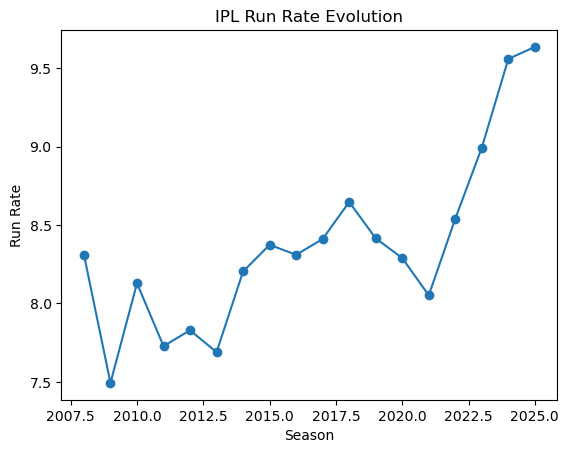

In [211]:
import matplotlib.pyplot as plt

plt.figure()
run_rate.plot(marker='o')
plt.title("IPL Run Rate Evolution")
plt.xlabel("Season")
plt.ylabel("Run Rate")
plt.show()

In [213]:
close_runs = match_df[
    (match_df["win_type"] == "runs") &
    (match_df["win_margin"] <= 10)
].shape[0]

close_wickets = match_df[
    (match_df["win_type"] == "wickets") &
    (match_df["win_margin"] <= 2)
].shape[0]

total_matches = match_df.shape[0]

close_percentage = ((close_runs + close_wickets) / total_matches) * 100

close_runs, close_wickets, close_percentage

(128, 16, 12.318220701454234)

In [215]:
match_df["is_close"] = (
    ((match_df["win_type"] == "runs") & (match_df["win_margin"] <= 10)) |
    ((match_df["win_type"] == "wickets") & (match_df["win_margin"] <= 2))
)

close_by_season = match_df.groupby("ipl_season")["is_close"].mean() * 100

close_by_season

ipl_season
2008    15.517241
2009    14.035088
2010     6.666667
2011     8.219178
2012    10.810811
2013    10.526316
2014     6.666667
2015    16.949153
2016    13.333333
2017    13.559322
2018    16.666667
2019    10.000000
2020     6.666667
2021    18.333333
2022     9.459459
2023    20.270270
2024    12.676056
2025    12.162162
Name: is_close, dtype: float64

In [219]:
super_over_match = df.groupby("match_id")["is_super_over"].any().reset_index()

super_over_match.columns = ["match_id", "is_super_over"]

In [221]:
match_df = match_df.merge(
    super_over_match,
    on="match_id",
    how="left"
)

In [223]:
super_over_count = match_df["is_super_over"].sum()
super_over_pct = (super_over_count / match_df.shape[0]) * 100

super_over_count, super_over_pct

(15, 1.2831479897348161)

In [225]:
dl_match = df.groupby("match_id")["is_dl_method"].any().reset_index()

dl_match.columns = ["match_id", "is_dl_method"]

match_df = match_df.merge(
    dl_match,
    on="match_id",
    how="left"
)

In [227]:
dl_count = match_df["is_dl_method"].sum()
dl_pct = (dl_count / match_df.shape[0]) * 100

dl_count, dl_pct

(22, 1.8819503849443968)

In [229]:
top_runs = df.groupby("batter")["runs_batter"].sum().sort_values(ascending=False)

top_runs.head(10)

batter
V Kohli           8671
RG Sharma         7048
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5235
AB de Villiers    5181
AM Rahane         5032
CH Gayle          4997
Name: runs_batter, dtype: int64

In [231]:
batter_stats = df.groupby("batter").agg({
    "runs_batter": "sum",
    "balls_faced": "sum"
})

batter_stats["strike_rate"] = (
    batter_stats["runs_batter"] /
    batter_stats["balls_faced"]
) * 100

# Apply minimum filter
batter_stats = batter_stats[batter_stats["balls_faced"] >= 1000]

batter_stats.sort_values("strike_rate", ascending=False).head(10)

,runs_batter,balls_faced,strike_rate
batter,,,
AD Russell,2655,1525,174.098361
N Pooran,2293,1359,168.727005
SP Narine,1780,1069,166.510758
Abhishek Sharma,1816,1114,163.016158
V Sehwag,2728,1755,155.441595
GJ Maxwell,2820,1818,155.115512
YBK Jaiswal,2166,1417,152.858151
AB de Villiers,5181,3411,151.890941
CH Gayle,4997,3346,149.342499


In [237]:
# Step 1: Total runs per batter per match
batter_match_runs = df.groupby(["match_id", "batter"])["runs_batter"].sum().reset_index()

# Step 2: Filter 50+ scores
fifties = batter_match_runs[batter_match_runs["runs_batter"] >= 50]

# Step 3: Count number of 50+ scores per batter
fifties_count = fifties.groupby("batter")["match_id"].count().sort_values(ascending=False)

fifties_count.head(10)

batter
V Kohli           72
DA Warner         66
S Dhawan          53
RG Sharma         49
KL Rahul          45
AB de Villiers    44
SK Raina          40
F du Plessis      39
CH Gayle          38
G Gambhir         36
Name: match_id, dtype: int64

In [239]:
batter_matches = df.groupby("batter")["match_id"].nunique()
batter_runs = df.groupby("batter")["runs_batter"].sum()

batter_avg = (batter_runs / batter_matches)

batter_avg = batter_avg[batter_matches >= 50]  # minimum 50 matches

batter_avg.sort_values(ascending=False).head(10)

batter
KL Rahul        38.777778
SE Marsh        36.072464
RD Gaikwad      35.742857
DA Warner       35.690217
CH Gayle        35.439716
JC Buttler      34.630252
MEK Hussey      34.086207
Shubman Gill    33.912281
V Kohli         33.478764
YBK Jaiswal     32.818182
dtype: float64

In [241]:
top_wickets = df.groupby("bowler")["bowler_wicket"].sum().sort_values(ascending=False)

top_wickets.head(10)

bowler
YS Chahal     221
B Kumar       198
PP Chawla     192
SP Narine     192
R Ashwin      187
JJ Bumrah     186
DJ Bravo      183
A Mishra      174
RA Jadeja     170
SL Malinga    170
Name: bowler_wicket, dtype: int64

In [243]:
bowler_stats = df.groupby("bowler").agg({
    "runs_bowler": "sum",
    "valid_ball": "sum",
    "bowler_wicket": "sum"
})

bowler_stats["economy"] = (
    bowler_stats["runs_bowler"] /
    bowler_stats["valid_ball"]
) * 6

# Minimum 1000 balls
bowler_stats = bowler_stats[bowler_stats["valid_ball"] >= 1000]

bowler_stats.sort_values("economy").head(10)

,runs_bowler,valid_ball,bowler_wicket,economy
bowler,,,,
M Muralitharan,1706,1528,64,6.698953
SP Narine,4933,4351,192,6.802574
DW Steyn,2523,2182,97,6.937672
Harbhajan Singh,4030,3416,150,7.078454
Rashid Khan,3781,3202,158,7.084947
SL Malinga,3366,2827,170,7.143969
R Ashwin,5652,4710,187,7.200000
M Kartik,1388,1149,31,7.248042
JJ Bumrah,4059,3359,186,7.250372


In [245]:
bowler_stats["strike_rate"] = (
    bowler_stats["valid_ball"] /
    bowler_stats["bowler_wicket"]
)

bowler_stats = bowler_stats[bowler_stats["bowler_wicket"] >= 50]

bowler_stats.sort_values("strike_rate").head(10)

,runs_bowler,valid_ball,bowler_wicket,economy,strike_rate
bowler,,,,,
AD Russell,2863,1806,123,9.511628,14.682927
K Rabada,2741,1911,122,8.605965,15.663934
Imran Tahir,1703,1316,82,7.764438,16.048780
HV Patel,3579,2424,151,8.858911,16.052980
MA Starc,1537,1064,65,8.667293,16.369231
SL Malinga,3366,2827,170,7.143969,16.629412
DJ Bravo,4360,3120,183,8.384615,17.049180
YS Chahal,5032,3791,221,7.964126,17.153846
KK Ahmed,2328,1556,89,8.976864,17.483146


In [247]:
death_df = df[df["over"] >= 15]

In [249]:
death_batter = death_df.groupby("batter").agg({
    "runs_batter": "sum",
    "balls_faced": "sum"
})

death_batter["strike_rate"] = (
    death_batter["runs_batter"] /
    death_batter["balls_faced"]
) * 100

# Minimum filter
death_batter = death_batter[death_batter["balls_faced"] >= 500]

death_batter.sort_values("strike_rate", ascending=False).head(10)

,runs_batter,balls_faced,strike_rate
batter,,,
AB de Villiers,1868,838,222.911695
AD Russell,1432,731,195.896033
V Kohli,1507,808,186.509901
RG Sharma,1527,843,181.138790
Yuvraj Singh,906,501,180.838323
MS Dhoni,3468,1982,174.974773
DJ Bravo,909,522,174.137931
SO Hetmyer,933,537,173.743017
KD Karthik,1904,1098,173.406193


In [251]:
death_bowler = death_df.groupby("bowler").agg({
    "runs_bowler": "sum",
    "valid_ball": "sum",
    "bowler_wicket": "sum"
})

death_bowler["economy"] = (
    death_bowler["runs_bowler"] /
    death_bowler["valid_ball"]
) * 6

death_bowler["strike_rate"] = (
    death_bowler["valid_ball"] /
    death_bowler["bowler_wicket"]
)

# Minimum 300 balls in death overs
death_bowler = death_bowler[death_bowler["valid_ball"] >= 300]

death_bowler.sort_values("economy").head(10)

,runs_bowler,valid_ball,bowler_wicket,economy,strike_rate
bowler,,,,,
SP Narine,1287,1051,75,7.347288,14.013333
SL Malinga,1464,1117,108,7.863921,10.342593
JJ Bumrah,1837,1345,101,8.194796,13.316832
R Ashwin,825,601,36,8.236273,16.694444
Kuldeep Yadav,462,334,29,8.299401,11.517241
DW Steyn,877,634,50,8.299685,12.680000
CV Varun,422,304,17,8.328947,17.882353
Rashid Khan,812,576,41,8.458333,14.048780
PP Chawla,641,444,39,8.662162,11.384615


In [253]:
powerplay_df = df[df["over"] < 6]

In [257]:
pp_batter = powerplay_df.groupby("batter").agg({
    "runs_batter": "sum",
    "balls_faced": "sum"
})

pp_batter["strike_rate"] = (
    pp_batter["runs_batter"] /
    pp_batter["balls_faced"]
) * 100

pp_batter = pp_batter[pp_batter["balls_faced"] >= 500]

pp_batter.sort_values("strike_rate", ascending=False).head(20)

,runs_batter,balls_faced,strike_rate
batter,,,
SP Narine,1150,673,170.876672
Abhishek Sharma,1018,635,160.314961
YBK Jaiswal,1378,869,158.573072
JM Bairstow,944,625,151.040000
P Simran Singh,872,585,149.059829
PP Shaw,1347,919,146.572361
CA Lynn,779,540,144.259259
V Sehwag,1593,1105,144.162896
SA Yadav,936,668,140.119760


In [261]:
pp_bowler = powerplay_df.groupby("bowler").agg({
    "runs_bowler": "sum",
    "valid_ball": "sum",
    "bowler_wicket": "sum"
})

pp_bowler["economy"] = (
    pp_bowler["runs_bowler"] /
    pp_bowler["valid_ball"]
) * 6

pp_bowler["strike_rate"] = (
    pp_bowler["valid_ball"] /
    pp_bowler["bowler_wicket"]
)

pp_bowler = pp_bowler[pp_bowler["valid_ball"] >= 500]

pp_bowler.sort_values("economy").head(10)

,runs_bowler,valid_ball,bowler_wicket,economy,strike_rate
bowler,,,,,
SL Malinga,1161,1110,37,6.275676,30.000000
DW Steyn,1199,1140,34,6.310526,33.529412
JC Archer,582,546,23,6.395604,23.739130
B Kumar,2542,2339,80,6.520735,29.237500
P Kumar,1754,1572,40,6.694656,39.300000
JJ Bumrah,1282,1144,41,6.723776,27.902439
Z Khan,1452,1292,52,6.743034,24.846154
SP Narine,1059,924,27,6.876623,34.222222
MM Patel,762,654,29,6.990826,22.551724
